[[  1.         143.63502971   1.         ...  48.           8.2976312
    5.93573364]
 [  1.         287.6785766    1.         ...  37.           6.06146565
   10.8273922 ]
 [  1.         232.99848545   1.         ...  14.           2.91144248
    6.90459907]
 ...
 [  1.          69.43365924   1.         ...  18.           8.62972399
    6.26326404]
 [  1.         293.59870192   5.         ...  41.           5.31889079
   16.99068431]
 [  1.         296.55268612   4.         ...  20.           7.89432194
    1.7797943 ]]
OLS Weights: [-2.87338195e+04  1.01739362e+01  5.05447199e+02  2.95902915e+02
  2.15230472e+02  1.50690894e+01  2.98804288e+02  4.79540958e+02
  1.13504634e+01  4.81381638e+01 -2.01031809e+01]
RSS: 16876199.730578266
MSE: 35906.80793740057


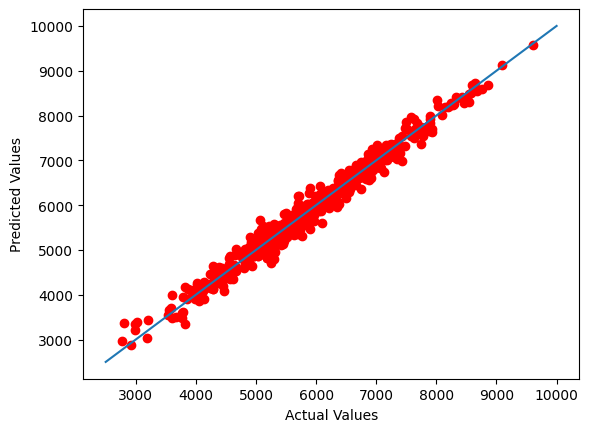

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('data.csv')
df = df.dropna()
matrix = df.values
z = matrix[:,-1]
y1 = np.transpose(z)
matrix[:,0] = 1
X1 = np.delete(matrix, -1, axis=1)
def ols_estimator(X, y):
    # OLS formula: W = (X^T X)^(-1) X^T y
    X_transpose = X.T
    W_ols = np.linalg.inv(X_transpose @ X) @ X_transpose @ y
    return W_ols
def mle_estimator(X, y):
    # MLE gives the same weights as OLS for linear regression
    W_mle = ols_estimator(X, y)  # Reuse the OLS function for simplicity
    # Estimate sigma^2
    residuals = y - X @ W_mle
    rss = np.sum(residuals**2)
    sigma2 = np.mean(residuals**2)
    return W_mle, rss, sigma2
W_ols = ols_estimator(X1, y1)
y_mean = np.mean(y1)
W_mle, rss, sigma2 = mle_estimator(X1, y1)
y_pred_ols = X1 @ W_ols
y_pred_mle = X1 @ W_mle
print("OLS Weights:", W_ols)
print("RSS:", rss)
print("MSE:", sigma2)
plt.plot(y1, y_pred_ols, 'ro')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
x = np.linspace(2500, 10000, 75000)
y = x
plt.plot(x, y, label='y = x')

plt.show()



OLS Weights: [5837.21276596  766.57952848  730.69121468  241.83110581  173.51166408
  529.49520517  148.9632351   239.71620164  131.70061262  137.40000391
 -112.49092072]
RSS: 16876199.73057825
MSE: 35906.80793740053


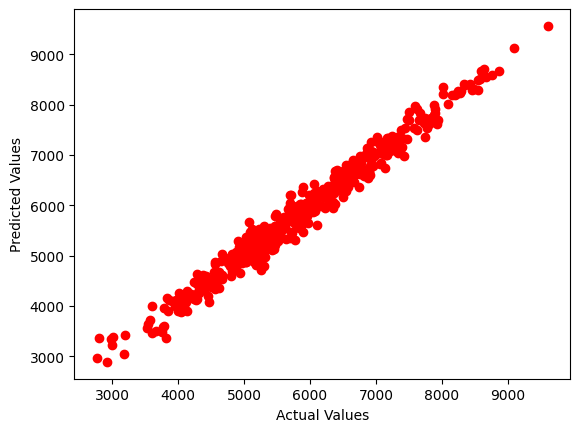

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('data.csv')
df = df.dropna()
matrix = df.values
z = matrix[:,-1]
y1 = np.transpose(z)
matrix[:,0] = 1
X1 = np.delete(matrix, -1, axis=1)
for j in range(X1.shape[1]) :
  if j != 0 :
    mean = np.mean(X1[:,j])
    std = np.std(X1[:,j])
    X1[:,j] = (X1[:,j] - mean) / std
def ols_estimator(X, y):
    # OLS formula: W = (X^T X)^(-1) X^T y
    X_transpose = X.T
    W_ols = np.linalg.inv(X_transpose @ X) @ X_transpose @ y
    return W_ols
W_ols = ols_estimator(X1, y1)
y_mean = np.mean(y1)
y_pred_ols = X1 @ W_ols
print("OLS Weights:", W_ols)
plt.plot(y1, y_pred_ols, 'ro')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
def mle_estimator(X, y):
    # MLE gives the same weights as OLS for linear regression
    W_mle = ols_estimator(X, y)  # Reuse the OLS function for simplicity
    # Estimate sigma^2
    residuals = y - X @ W_mle
    rss = np.sum(residuals**2)
    sigma2 = np.mean(residuals**2)
    return W_mle, rss, sigma2
W_mle, rss, sigma2 = mle_estimator(X1, y1)
print("RSS:", rss)
print("MSE:", sigma2)

OLS Weights: [ 5.83721277e+03  7.66017487e+02  7.32099432e+02  2.42933470e+02
  1.75241780e+02  5.30946502e+02  1.84005401e+02 -2.92265178e+02
  1.32110017e+02  1.37594110e+02 -1.11789075e+02  1.57665629e+01
 -1.27072379e+01  4.87238941e+00 -5.93735510e+00 -6.27513332e+00
  3.90200267e+01  6.66135024e+02  1.22708619e+01 -3.05368854e+00
 -7.19441360e+00]
RSS: 24996248.860201713
MSE: 53183.508213195135


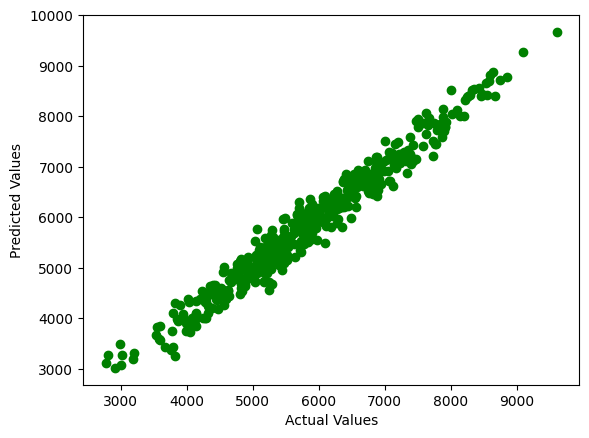

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('data.csv')
df = df.dropna()
matrix = df.values
z = matrix[:,-1]
y1 = np.transpose(z)
matrix[:,0] = 1
X1 = np.delete(matrix, -1, axis=1)
X2 = np.zeros(X1.shape)
for j in range(X1.shape[1]) :
  if j != 0 :
    mean = np.mean(X1[:,j])
    std = np.std(X1[:,j])
    X1[:,j] = (X1[:,j] - mean) / std
for j in range(X1.shape[1]) :
  for i in range(X1.shape[0]) :
    X2[i,j] = X1[i,j]**2
X3 = np.concatenate((X1.copy(), X2[:, 1:]), axis=1)
for j in range(X3.shape[1]) :
  if j != 0 :
    mean = np.mean(X3[:,j])
    std = np.std(X3[:,j])
    if std != 0 :
      X3[:,j] = (X3[:,j] - mean) / std
def ols_estimator(X, y):
    # OLS formula: W = (X^T X)^(-1) X^T y
    X_transpose = X.T
    W_ols = np.linalg.inv(X_transpose @ X) @ X_transpose @ y
    return W_ols
W_ols = ols_estimator(X3, y1)
y_mean = np.mean(y1)
y_pred_ols = X3 @ W_ols
print("OLS Weights:", W_ols)
plt.plot(y1, y_pred_ols, 'go')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
def mle_estimator(X, y):
    # MLE gives the same weights as OLS for linear regression
    W_mle = ols_estimator(X, y)  # Reuse the OLS function for simplicity
    # Estimate sigma^2
    residuals = y - X @ W_mle
    rss = np.sum(residuals**2)
    sigma2 = np.mean(residuals**2)
    return W_mle, rss, sigma2
W_mle, rss, sigma2 = mle_estimator(X3, y1)
print("RSS:", rss)
print("MSE:", sigma2)